# 06 - Evaluation on the test set

The test split (2,203 images) is only used here, after all models were trained. Each model's output is turned into three predictions (`src/evaluation.py`):

- **fruit type** (8 classes): for Model 1 the probabilities of the fresh and the spoiled class of each fruit are added up;
- **freshness**: spoiled when P(spoiled) >= 0.5; spoiled is the positive class for precision, recall and F1;
- **joint** (16 classes): fruit and freshness both right. This is the main score, because it is exactly the task of Model 1.

Precision, recall and F1 of the fruit and joint views are macro averages over the classes.

In [1]:
import os, sys
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
sys.path.insert(0, os.path.abspath(".."))
import tensorflow as tf
tf.get_logger().setLevel("ERROR")

import time
import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay

from src.config import COMBINED_NAMES, FIGURES_DIR, IMG_SIZE, MODELS_DIR, PREDICTIONS_DIR, PROJECT_ROOT, REPORTS_DIR
from src.data_pipeline import load_split, make_dataset
from src.evaluation import compute_metrics, confusion_matrices, predict, predictions_table
%matplotlib inline

In [2]:
MAIN = {
    "model1_simple_cnn": "Model 1 - Simple CNN (16 classes)",
    "model2_multitask_cnn": "Model 2 - Multi-task residual CNN",
    "model3_mobilenet_v2": "Model 3 - MobileNetV2 fine-tuned",
}
SHORT = {run: label.split(" - ")[0] for run, label in MAIN.items()}
FINETUNE = {
    "model3_ft_none": "none (frozen)",
    "model3_ft_block16": "block 16",
    "model3_mobilenet_v2": "block 13 (main)",
    "model3_ft_block10": "block 10",
    "model3_ft_block6": "block 6",
    "model3_ft_all": "all layers",
}
RUNS = list(MAIN) + [f"{run}_noaug" for run in MAIN] + [run for run in FINETUNE if run not in MAIN]
log = pd.read_csv(REPORTS_DIR / "experiment_log.csv").set_index("run")

## 1. Predictions of all 11 runs

The test predictions are also saved image by image in `reports/predictions/` for notebooks 07 and 08.

In [3]:
val_df, test_df = load_split("val"), load_split("test")
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)
rows, cms = [], {}
for run in RUNS:
    model = keras.models.load_model(MODELS_DIR / f"{run}.keras")
    mode = "combined" if run.startswith("model1") else "multitask"
    val_pred = predict(model, make_dataset("val", label_mode=mode, batch_size=64))
    test_pred = predict(model, make_dataset("test", label_mode=mode, batch_size=64))
    predictions_table(test_df, test_pred).to_csv(PREDICTIONS_DIR / f"{run}_test.csv", index=False)
    if run in MAIN:
        cms[run] = confusion_matrices(test_df, test_pred)
    rows.append({
        "run": run,
        **compute_metrics(test_df, test_pred),
        **{f"val_{k}": v for k, v in compute_metrics(val_df, val_pred).items()},
        "joint_errors": int((test_pred["joint_pred"] != test_df["combined_label"]).sum()),
        "params": model.count_params(),
        "trainable_params": int(sum(np.prod(w.shape) for w in model.trainable_weights)),
        **log.loc[run, ["train_minutes", "unfrozen_layers", "fine_tune_from", "augmentation"]].to_dict(),
    })
    keras.backend.clear_session()

results = pd.DataFrame(rows).set_index("run")
results[["joint_accuracy", "joint_f1", "fruit_accuracy", "freshness_f1", "freshness_auc", "joint_errors", "val_joint_accuracy"]].round(4)

,joint_accuracy,joint_f1,fruit_accuracy,freshness_f1,freshness_auc,joint_errors,val_joint_accuracy
run,,,,,,,
model1_simple_cnn,0.9809,0.9794,0.9909,0.9883,0.9993,42,0.9750
model2_multitask_cnn,0.9796,0.9785,0.9873,0.9891,0.9993,45,0.9755
model3_mobilenet_v2,0.9973,0.9968,1.0000,0.9975,0.9998,6,0.9991
model1_simple_cnn_noaug,0.9237,0.9199,0.9564,0.9562,0.9894,168,0.9278
model2_multitask_cnn_noaug,0.9805,0.9800,0.9887,0.9907,0.9994,43,0.9764
model3_mobilenet_v2_noaug,0.9932,0.9927,0.9959,0.9975,0.9999,15,0.9986
model3_ft_none,0.9818,0.9797,0.9950,0.9869,0.9990,40,0.9923
model3_ft_block16,0.9936,0.9929,0.9986,0.9950,0.9997,14,0.9991
model3_ft_block10,0.9977,0.9973,1.0000,0.9979,0.9999,5,0.9991


## 2. The three models

In [4]:
COLUMNS = {"joint_accuracy": "Accuracy", "joint_precision": "Precision", "joint_recall": "Recall", "joint_f1": "F1-score",
           "fruit_accuracy": "Fruit acc.", "freshness_f1": "Freshness F1", "freshness_auc": "Freshness AUC",
           "joint_errors": "Wrong images", "params": "Params"}
main = results.loc[list(MAIN), list(COLUMNS)].rename(columns=COLUMNS, index=MAIN)
main.index.name = "Model"
main[["Wrong images", "Params"]] = main[["Wrong images", "Params"]].astype(int)
main.round(4)

,Accuracy,Precision,Recall,F1-score,Fruit acc.,Freshness F1,Freshness AUC,Wrong images,Params
Model,,,,,,,,,
Model 1 - Simple CNN (16 classes),0.9809,0.9804,0.9789,0.9794,0.9909,0.9883,0.9993,42,3751632
Model 2 - Multi-task residual CNN,0.9796,0.9781,0.9796,0.9785,0.9873,0.9891,0.9993,45,4986345
Model 3 - MobileNetV2 fine-tuned,0.9973,0.9964,0.9973,0.9968,1.0000,0.9975,0.9998,6,2505033


The chart shows error rates (100 % - accuracy) starting from zero: all accuracies are close to 100 %, and accuracy bars on a cut axis would exaggerate the differences.

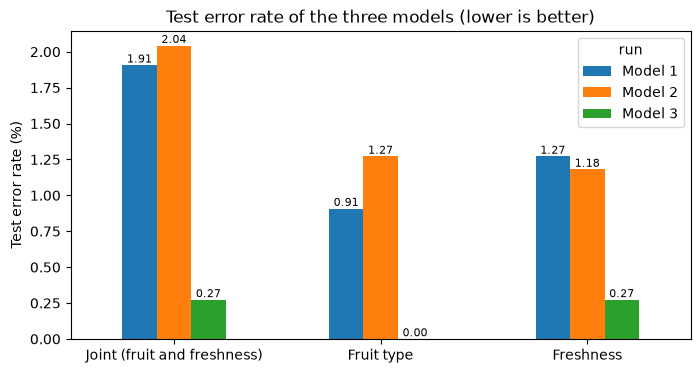

In [5]:
views = {"joint_accuracy": "Joint (fruit and freshness)", "fruit_accuracy": "Fruit type", "freshness_accuracy": "Freshness"}
errors = 100 * (1 - results.loc[list(MAIN), list(views)].rename(index=SHORT, columns=views))
ax = errors.T.plot.bar(figsize=(8, 4), rot=0)
for bars in ax.containers:
    ax.bar_label(bars, fmt="%.2f", fontsize=8)
ax.set_ylabel("Test error rate (%)")
ax.set_title("Test error rate of the three models (lower is better)")
plt.savefig(FIGURES_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")

Model 3 is the best on all three views: 6 wrong test images, all of them freshness errors (the fruit type is always right). Models 1 and 2 are close, 42 and 45 wrong images: Model 1 is better on the fruit type, Model 2 slightly better on freshness.

Confusion matrices of the joint (16-class) predictions; the fruit and freshness matrices are saved in `figures/confusion_matrices/`.

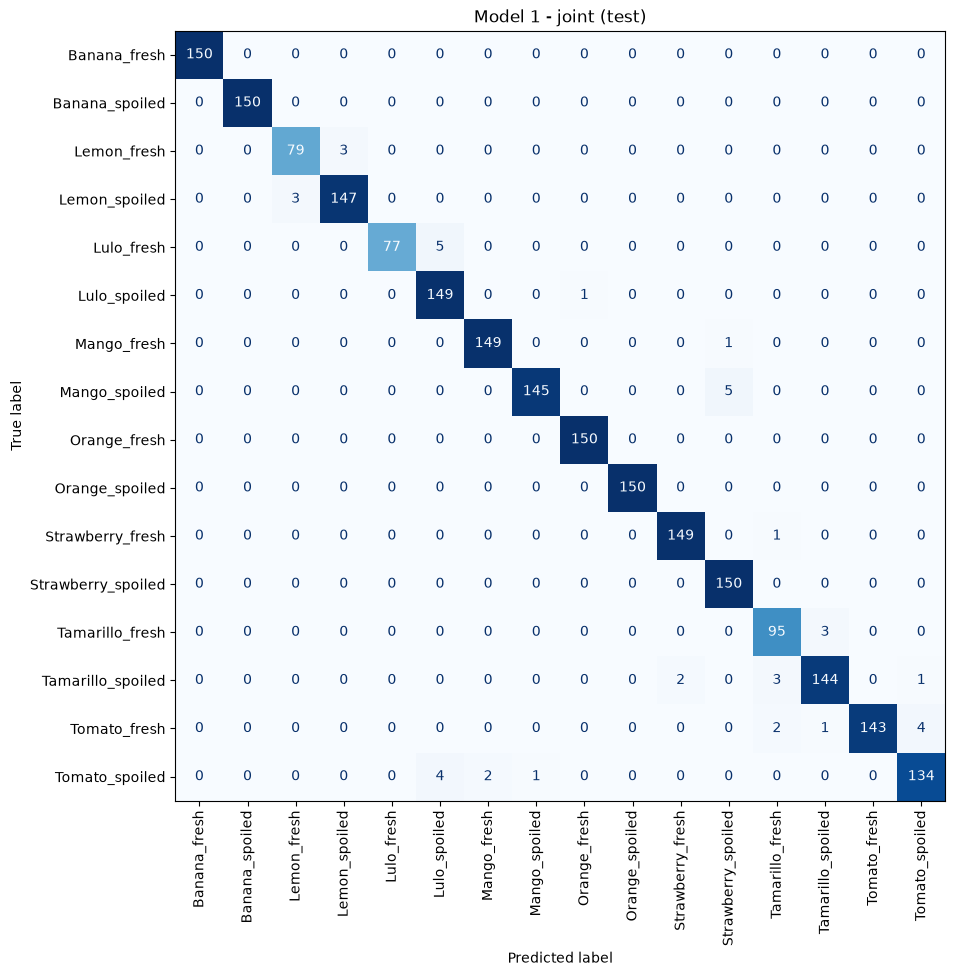

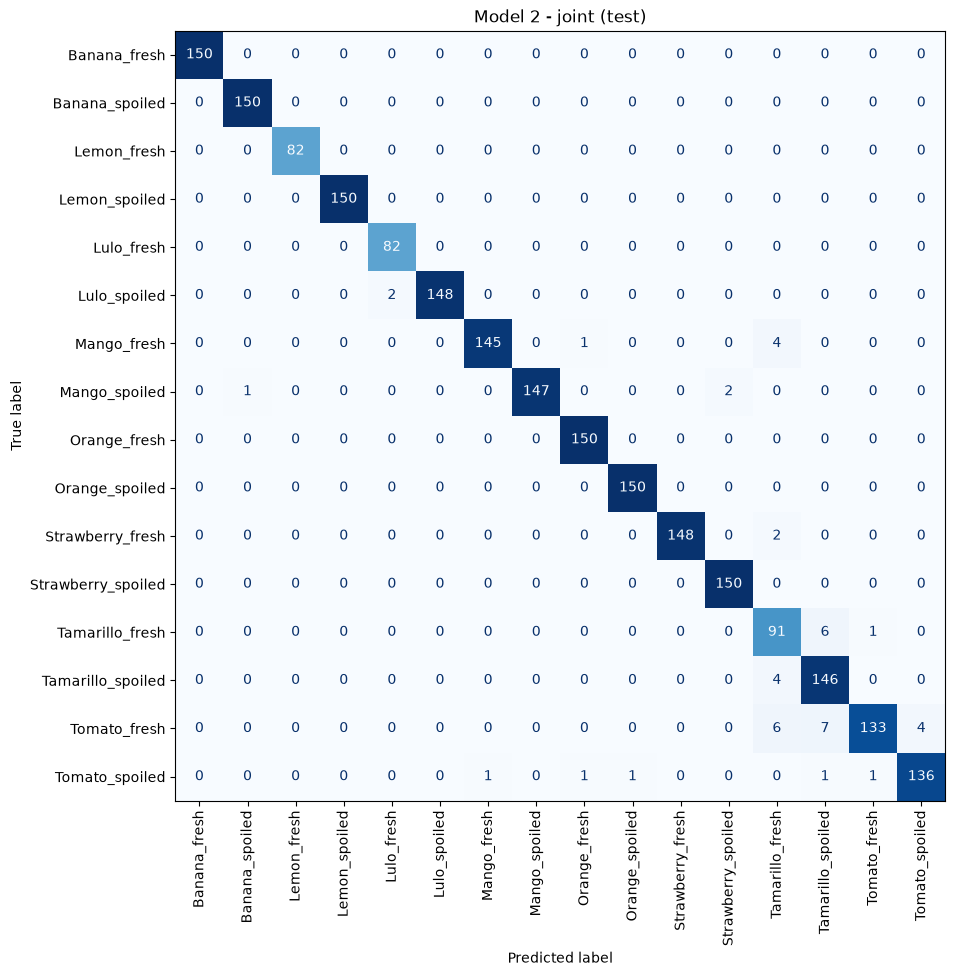

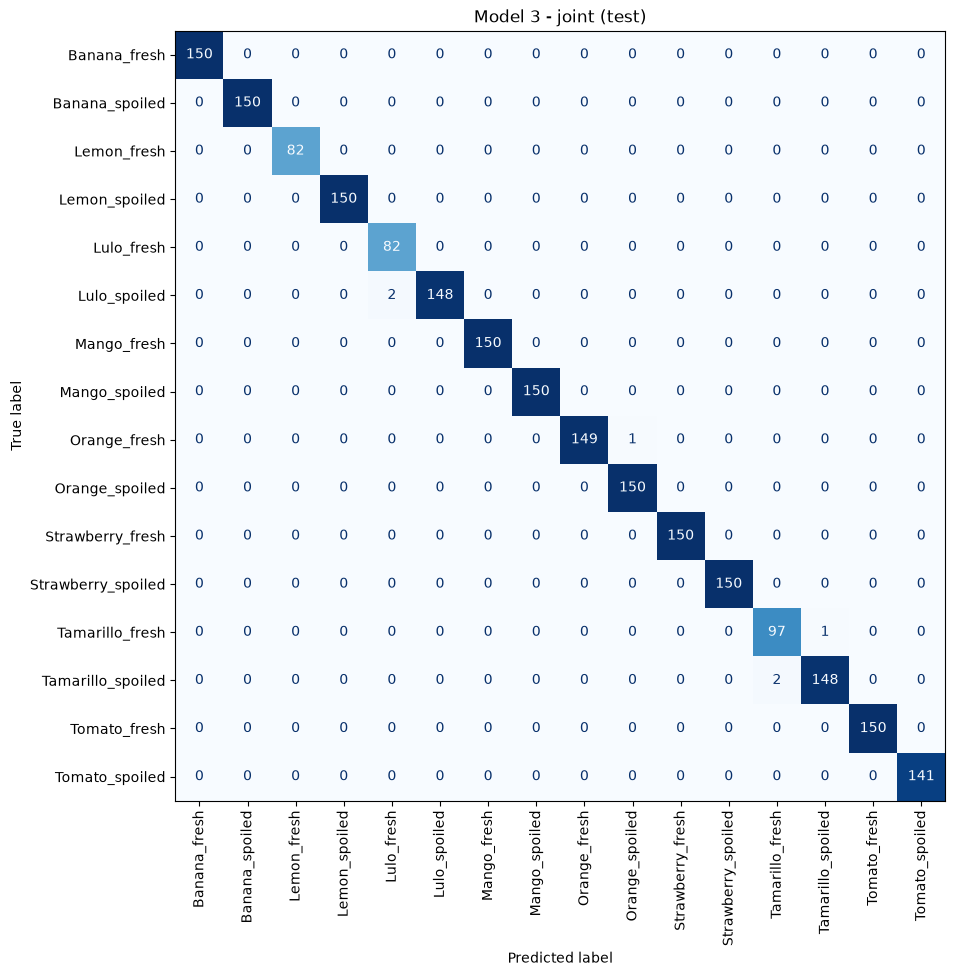

In [6]:
for run, matrices in cms.items():
    for view, (cm, labels) in matrices.items():
        size = {2: 3.5, 8: 6, 16: 10}[len(labels)]
        fig, ax = plt.subplots(figsize=(size, size))
        # ma trận nhầm lẫn: hàng = nhãn thật, cột = nhãn dự đoán, đường chéo = đoán đúng
        ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=90)
        ax.set_title(f"{SHORT[run]} - {view} (test)")
        fig.savefig(FIGURES_DIR / "confusion_matrices" / f"{run}_{view}.png", dpi=150, bbox_inches="tight")
        if view != "joint":
            plt.close(fig)

Most mistakes of Models 1 and 2 are either fresh/spoiled of the same fruit or between fruits that look alike (tomato and tamarillo, spoiled mango and spoiled strawberry). Notebook 07 looks at the errors in detail.

## 3. Ablation: data augmentation

In [7]:
aug = pd.DataFrame([{
    "Model": label,
    "Joint acc. (aug)": results.loc[run, "joint_accuracy"],
    "Joint acc. (no aug)": results.loc[f"{run}_noaug", "joint_accuracy"],
    "Joint F1 (aug)": results.loc[run, "joint_f1"],
    "Joint F1 (no aug)": results.loc[f"{run}_noaug", "joint_f1"],
    "Errors (aug)": results.loc[run, "joint_errors"],
    "Errors (no aug)": results.loc[f"{run}_noaug", "joint_errors"],
} for run, label in MAIN.items()]).set_index("Model")
aug.round(4)

,Joint acc. (aug),Joint acc. (no aug),Joint F1 (aug),Joint F1 (no aug),Errors (aug),Errors (no aug)
Model,,,,,,
Model 1 - Simple CNN (16 classes),0.9809,0.9237,0.9794,0.9199,42,168
Model 2 - Multi-task residual CNN,0.9796,0.9805,0.9785,0.9800,45,43
Model 3 - MobileNetV2 fine-tuned,0.9973,0.9932,0.9968,0.9927,6,15


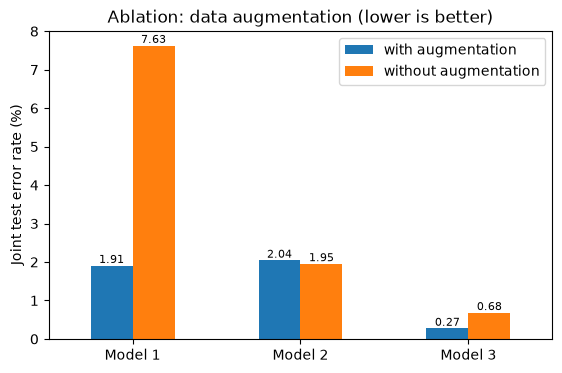

In [8]:
err = pd.DataFrame({"with augmentation": 100 * (1 - aug["Joint acc. (aug)"].values),
                    "without augmentation": 100 * (1 - aug["Joint acc. (no aug)"].values)}, index=SHORT.values())
ax = err.plot.bar(figsize=(6.5, 4), rot=0)
for bars in ax.containers:
    ax.bar_label(bars, fmt="%.2f", fontsize=8)
ax.set_ylabel("Joint test error rate (%)")
ax.set_title("Ablation: data augmentation (lower is better)")
plt.savefig(FIGURES_DIR / "ablation_augmentation.png", dpi=150, bbox_inches="tight")

Without augmentation Model 1 drops from 98.1 % to 92.4 % (168 wrong images instead of 42): it overfits through its large dense layer (notebook 03). Model 2 stays the same, and Model 3 becomes a little worse (15 instead of 6 wrong images).

## 4. Model size and speed

All variants are timed the same way on our CPU: seconds per training step (batch of 32 augmented images, measured after one warm-up epoch) and the median inference time per image. The wall-clock training times in the experiment log are not comparable, because the computer was not always idle during training.

The table below was measured on 2026-10-04 with the laptop idle and plugged in. Timings change a lot with the power mode (on battery they were about twice as slow), so `MEASURE = False` loads that table; `MEASURE = True` measures again.

In [9]:
MEASURE = False
SPEED_RUNS = ["model1_simple_cnn", "model2_multitask_cnn"] + list(FINETUNE)


def seconds_per_step(model, label_mode, steps=20):
    ds = make_dataset("train", label_mode=label_mode, batch_size=32, augment=True, limit=41).take(steps).repeat()
    t = []
    for _ in range(2):  # lần chạy đầu chậm hơn vì khởi tạo, chỉ lấy thời gian lần thứ hai
        t0 = time.perf_counter()
        model.fit(ds, epochs=1, steps_per_epoch=steps, shuffle=False, verbose=0)
        t.append(time.perf_counter() - t0)
    return t[-1] / steps


def ms_per_image(model, batch_size, runs=30):
    x = np.random.default_rng(0).uniform(0, 255, (batch_size, IMG_SIZE, IMG_SIZE, 3)).astype("float32")
    for _ in range(5):
        model.predict_on_batch(x)
    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        model.predict_on_batch(x)
        times.append(time.perf_counter() - t0)
    return 1000 * np.median(times) / batch_size


if MEASURE:
    rows = []
    for run in SPEED_RUNS:
        model = keras.models.load_model(MODELS_DIR / f"{run}.keras")
        bs1, bs32 = ms_per_image(model, 1), ms_per_image(model, 32, runs=10)
        step = seconds_per_step(model, "combined" if run.startswith("model1") else "multitask")
        rows.append({"run": run, "total_params": model.count_params(), "trainable_params": results.loc[run, "trainable_params"],
                     "train_s_per_step": round(step, 3), "infer_ms_per_img_bs1": round(bs1, 2),
                     "infer_ms_per_img_bs32": round(bs32, 2)})
        keras.backend.clear_session()
    pd.DataFrame(rows).set_index("run").to_csv(REPORTS_DIR / "training_cost.csv")

cost = pd.read_csv(REPORTS_DIR / "training_cost.csv").set_index("run")
print(f"CPU only ({os.cpu_count()} logical cores), TensorFlow {tf.__version__}")
cost.loc[SPEED_RUNS, ["total_params", "trainable_params", "train_s_per_step", "infer_ms_per_img_bs1", "infer_ms_per_img_bs32"]]

CPU only (20 logical cores), TensorFlow 2.21.0


,total_params,trainable_params,train_s_per_step,infer_ms_per_img_bs1,infer_ms_per_img_bs32
run,,,,,
model1_simple_cnn,3751632,3751632,0.691,15.48,6.01
model2_multitask_cnn,4986345,4980521,0.877,20.32,6.35
model3_ft_none,2505033,247049,0.466,34.66,12.54
model3_ft_block16,2505033,1126089,0.492,34.83,12.50
model3_mobilenet_v2,2505033,1910409,0.531,35.06,12.51
model3_ft_block10,2505033,2206857,0.574,36.13,12.97
model3_ft_block6,2505033,2384841,0.600,34.65,12.62
model3_ft_all,2505033,2436809,0.931,36.03,12.72


Model 3 has the fewest parameters but is the slowest at inference on a CPU (about 35 ms per image against 15-20 ms): it is much deeper (about 150 layers), and the time depends more on the number of layers and operations than on the number of parameters. The training cost of Model 3 grows with the number of fine-tuned layers: 0.47 s per step with the frozen backbone, 0.53 s from block 13 and 0.93 s for all layers.

## 5. Ablation: fine-tuning depth (Model 3)

In [10]:
ft = pd.DataFrame([{
    "Unfrozen from": setting,
    "Unfrozen layers": 0 if run == "model3_ft_none" else int(results.loc[run, "unfrozen_layers"]),
    "Trainable params": results.loc[run, "trainable_params"],
    "Val joint acc.": results.loc[run, "val_joint_accuracy"],
    "Test joint acc.": results.loc[run, "joint_accuracy"],
    "Test joint F1": results.loc[run, "joint_f1"],
    "Test freshness F1": results.loc[run, "freshness_f1"],
    "Test errors": results.loc[run, "joint_errors"],
    "Train s/step (CPU)": cost.loc[run, "train_s_per_step"],
} for run, setting in FINETUNE.items()])
ft.round(4)

,Unfrozen from,Unfrozen layers,Trainable params,Val joint acc.,Test joint acc.,Test joint F1,Test freshness F1,Test errors,Train s/step (CPU)
0,none (frozen),0,247049,0.9923,0.9818,0.9797,0.9869,40,0.466
1,block 16,11,1126089,0.9991,0.9936,0.9929,0.9950,14,0.492
2,block 13 (main),38,1910409,0.9991,0.9973,0.9968,0.9975,6,0.531
3,block 10,64,2206857,0.9991,0.9977,0.9973,0.9979,5,0.574
4,block 6,100,2384841,1.0000,0.9964,0.9954,0.9966,8,0.600
5,all layers,153,2436809,0.9995,0.9986,0.9982,0.9987,3,0.931


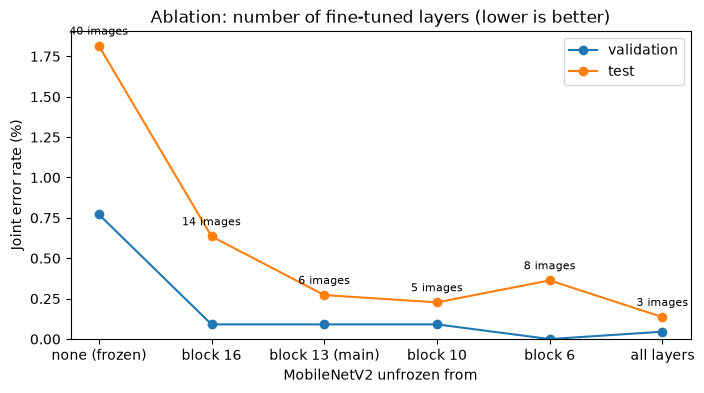

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ft["Unfrozen from"], 100 * (1 - ft["Val joint acc."]), marker="o", label="validation")
ax.plot(ft["Unfrozen from"], 100 * (1 - ft["Test joint acc."]), marker="o", label="test")
for i, (n, acc) in enumerate(zip(ft["Test errors"], ft["Test joint acc."])):
    ax.annotate(f"{n} images", (i, 100 * (1 - acc)), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
ax.set_ylim(bottom=0)
ax.set_xlabel("MobileNetV2 unfrozen from")
ax.set_ylabel("Joint error rate (%)")
ax.set_title("Ablation: number of fine-tuned layers (lower is better)")
ax.legend()
fig.savefig(FIGURES_DIR / "ablation_finetuning.png", dpi=150, bbox_inches="tight")

With the frozen backbone the model makes 40 test errors; fine-tuning from block 16 reduces them to 14 and from block 13 to 6. Unfreezing more layers changes the result by only a few images (5, 8 and 3), and the validation accuracy (99.9-100 % for every depth) cannot tell these settings apart. Picking the depth with the best test score would mean choosing on the test set, so block 13, fixed before this ablation, stays the main Model 3. Fine-tuning all layers gives the fewest errors but costs almost twice as much per training step (0.93 s against 0.53 s).

## 6. Misclassified test images of Model 3

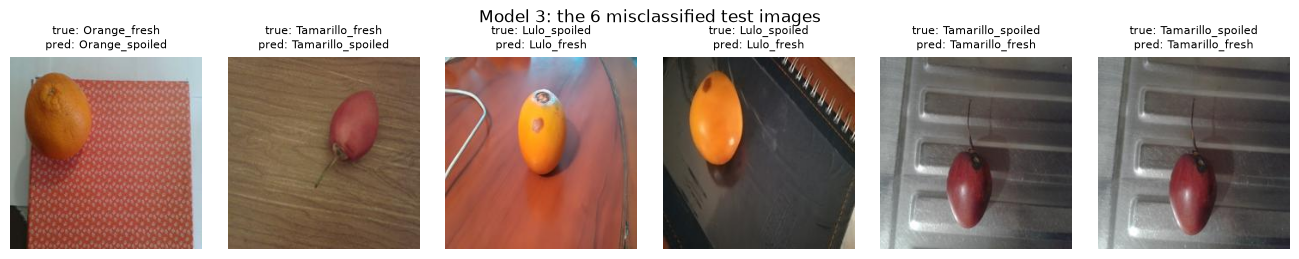

In [12]:
preds = pd.read_csv(PREDICTIONS_DIR / "model3_mobilenet_v2_test.csv")
wrong = preds[preds["joint_pred"] != preds["combined_label"]]
fig, axes = plt.subplots(1, len(wrong), figsize=(2.2 * len(wrong), 2.6))
for ax, r in zip(axes, wrong.itertuples()):
    ax.imshow(Image.open(PROJECT_ROOT / r.path))
    ax.set_title(f"true: {COMBINED_NAMES[r.combined_label]}\npred: {COMBINED_NAMES[r.joint_pred]}", fontsize=8)
    ax.axis("off")
fig.suptitle(f"Model 3: the {len(wrong)} misclassified test images")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "misclassified_samples.png", dpi=150, bbox_inches="tight")

## 7. Result files

`reports/final_metrics.csv` (every metric of every run) and `reports/results_summary.md` (the three tables above).

In [13]:
arch = {run: next(m for m in MAIN if m[:6] == run[:6]) for run in RUNS}
results["infer_ms_bs1"] = [cost.loc[arch[run], "infer_ms_per_img_bs1"] for run in results.index]
results.to_csv(REPORTS_DIR / "final_metrics.csv")

main["ms/img (CPU, batch 1)"] = cost.loc[list(MAIN), "infer_ms_per_img_bs1"].values
summary = [
    "# Results (test split, 2,203 images)",
    "",
    "Joint = fruit and freshness both correct (16 classes, macro precision/recall/F1). "
    "Freshness metrics use spoiled as the positive class. Made by notebooks/06_evaluation.ipynb.",
    "", "## Main comparison", "", main.round(4).reset_index().to_markdown(index=False),
    "", "## Ablation: data augmentation", "", aug.round(4).reset_index().to_markdown(index=False),
    "", "## Ablation: fine-tuning depth (Model 3)", "", ft.round(4).to_markdown(index=False), "",
]
(REPORTS_DIR / "results_summary.md").write_text("\n".join(summary), encoding="utf-8")
print("\n".join(summary))

# Results (test split, 2,203 images)

Joint = fruit and freshness both correct (16 classes, macro precision/recall/F1). Freshness metrics use spoiled as the positive class. Made by notebooks/06_evaluation.ipynb.

## Main comparison

| Model                             |   Accuracy |   Precision |   Recall |   F1-score |   Fruit acc. |   Freshness F1 |   Freshness AUC |   Wrong images |   Params |   ms/img (CPU, batch 1) |
|:----------------------------------|-----------:|------------:|---------:|-----------:|-------------:|---------------:|----------------:|---------------:|---------:|------------------------:|
| Model 1 - Simple CNN (16 classes) |     0.9809 |      0.9804 |   0.9789 |     0.9794 |       0.9909 |         0.9883 |          0.9993 |             42 |  3751632 |                   15.48 |
| Model 2 - Multi-task residual CNN |     0.9796 |      0.9781 |   0.9796 |     0.9785 |       0.9873 |         0.9891 |          0.9993 |             45 |  4986345 |                   20.